In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sqlalchemy import create_engine 

pd.set_option('display.max_columns',None) 
sns.set_theme(style="whitegrid", palette ="Set2")

In [17]:
import os 
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))

# Connect and Pull PostgreSQL 

In [ ]:
from dotenv import load_dotenv
import os
load_dotenv()
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
# Pull the features view we just created

df = pd.read_sql("SELECT * FROM  customer_features", engine)

print(f"Shape: {df.shape}")
print(f"Columns:{list(df.columns)}")
df.head()

Shape: (7043, 19)
Columns:['CustomerID', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Contract', 'Payment Method', 'Internet Service', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason', 'City', 'State', 'tenure_group', 'revenue_band', 'service_count', 'customer_value', 'risk_segment']


,CustomerID,Tenure Months,Monthly Charges,Total Charges,Contract,Payment Method,Internet Service,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,City,State,tenure_group,revenue_band,service_count,customer_value,risk_segment
0,3668-QPYBK,2,53.85,108.15,Month-to-month,Mailed check,DSL,Yes,1,86,3239,Competitor made better offer,Los Angeles,California,New,Medium,4,Standard,Low Risk
1,9237-HQITU,2,70.70,151.65,Month-to-month,Electronic check,Fiber optic,Yes,1,67,2701,Moved,Los Angeles,California,New,High,2,Standard,Low Risk
2,9305-CDSKC,8,99.65,820.5,Month-to-month,Electronic check,Fiber optic,Yes,1,86,5372,Moved,Los Angeles,California,New,Premium,6,Standard,Low Risk
3,7892-POOKP,28,104.80,3046.05,Month-to-month,Electronic check,Fiber optic,Yes,1,84,5003,Moved,Los Angeles,California,Mid,Premium,7,High Value,Low Risk
4,0280-XJGEX,49,103.70,5036.3,Month-to-month,Bank transfer (automatic),Fiber optic,Yes,1,89,5340,Competitor had better devices,Los Angeles,California,Loyal,Premium,7,High Value,Low Risk


# Basic Info


In [8]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== CHURN DISTRIBUTION ===")
print(df["Churn Label"].value_counts())
print(df["Churn Label"].value_counts(normalize=True).round(3) * 100)

=== DATA TYPES ===
CustomerID           object
Tenure Months         int64
Monthly Charges     float64
Total Charges        object
Contract             object
Payment Method       object
Internet Service     object
Churn Label          object
Churn Value           int64
Churn Score           int64
CLTV                  int64
Churn Reason         object
City                 object
State                object
tenure_group         object
revenue_band         object
service_count         int64
customer_value       object
risk_segment         object
dtype: object

=== MISSING VALUES ===
Churn Reason    5174
dtype: int64

=== CHURN DISTRIBUTION ===
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn Label
No     73.5
Yes    26.5
Name: proportion, dtype: float64


# Churn Distribution Plot

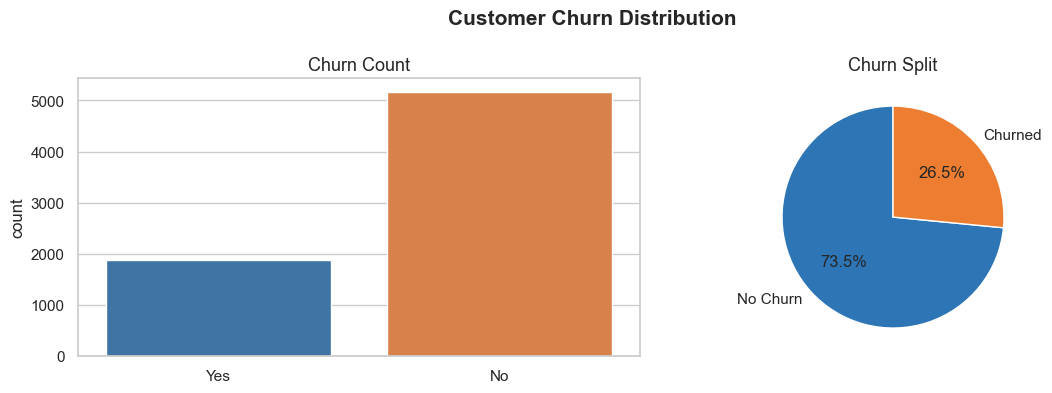

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x="Churn Label", data=df,hue="Churn Label", palette=["#2E75B6","#ED7D31"],legend=False, ax=axes[0])
axes[0].set_title("Churn Count", fontsize=13)
axes[0].set_xlabel("")

# Pie chart
churn_counts = df["Churn Label"].value_counts()
axes[1].pie(churn_counts, labels=["No Churn","Churned"],
            colors=["#2E75B6","#ED7D31"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Churn Split", fontsize=13)

plt.suptitle("Customer Churn Distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_DIR + "/data/processed/churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Tenure Group vs Churn

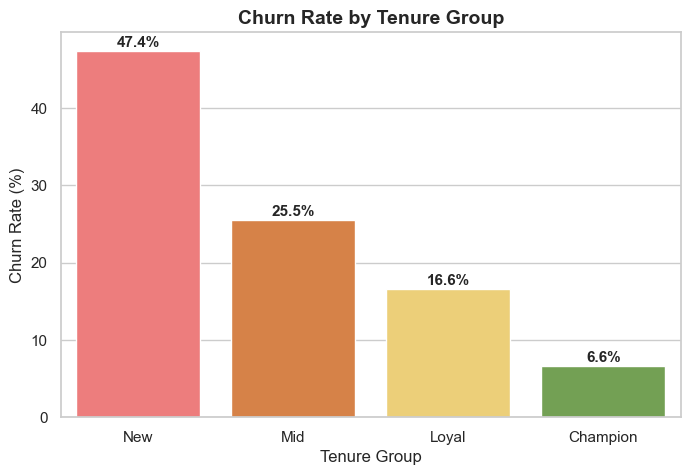

In [19]:
tenure_churn = df.groupby("tenure_group")["Churn Value"].mean().reset_index()
tenure_churn.columns = ["tenure_group", "churn_rate"]
tenure_churn["churn_rate"] = tenure_churn["churn_rate"] * 100

order = ["New", "Mid", "Loyal", "Champion"]
tenure_churn["tenure_group"] = pd.Categorical(tenure_churn["tenure_group"], categories=order, ordered=True)
tenure_churn = tenure_churn.sort_values("tenure_group")

plt.figure(figsize=(8, 5))
bars = sns.barplot(x="tenure_group", y="churn_rate", data=tenure_churn,hue="tenure_group", dodge=False, legend=False,
                   palette=["#FF6B6B","#ED7D31","#FFD966","#70AD47"])
for bar, val in zip(bars.patches, tenure_churn["churn_rate"]):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.title("Churn Rate by Tenure Group", fontsize=14, fontweight="bold")
plt.xlabel("Tenure Group"); plt.ylabel("Churn Rate (%)")
plt.savefig(BASE_DIR + "/data/processed/churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

# Revenue Band vs Churn

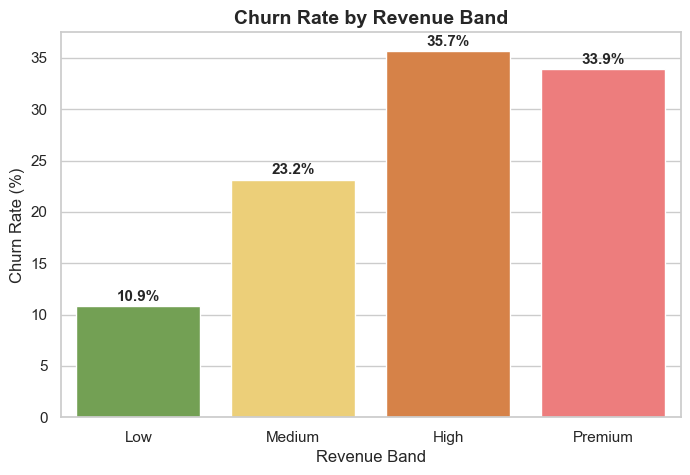

In [21]:
rev_churn = df.groupby("revenue_band")["Churn Value"].mean().reset_index()
rev_churn.columns = ["revenue_band", "churn_rate"]
rev_churn["churn_rate"] = rev_churn["churn_rate"] * 100

order = ["Low", "Medium", "High", "Premium"]
rev_churn["revenue_band"] = pd.Categorical(rev_churn["revenue_band"], categories=order, ordered=True)
rev_churn = rev_churn.sort_values("revenue_band")

plt.figure(figsize=(8, 5))
bars = sns.barplot(x="revenue_band", y="churn_rate", data=rev_churn,hue="revenue_band", dodge=False, legend=False,
                   palette=["#70AD47","#FFD966","#ED7D31","#FF6B6B"])
for bar, val in zip(bars.patches, rev_churn["churn_rate"]):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.title("Churn Rate by Revenue Band", fontsize=14, fontweight="bold")
plt.xlabel("Revenue Band"); plt.ylabel("Churn Rate (%)")
plt.savefig(BASE_DIR + "/data/processed/churn_by_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

# Contract Type vs Churn

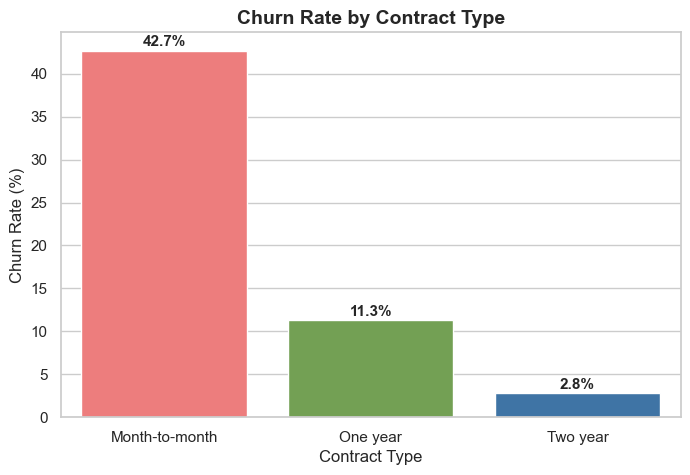

In [22]:
contract_churn = df.groupby("Contract")["Churn Value"].mean().reset_index()
contract_churn["Churn Value"] = contract_churn["Churn Value"] * 100

plt.figure(figsize=(8, 5))
bars = sns.barplot(x="Contract", y="Churn Value", data=contract_churn,hue="Contract", dodge=False, legend=False,
                   palette=["#FF6B6B","#70AD47","#2E75B6"])
for bar, val in zip(bars.patches, contract_churn["Churn Value"]):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.title("Churn Rate by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel("Contract Type"); plt.ylabel("Churn Rate (%)")
plt.savefig(BASE_DIR + "/data/processed/churn_by_contract.png", dpi=150, bbox_inches="tight")
plt.show()

# Numeric Distributions

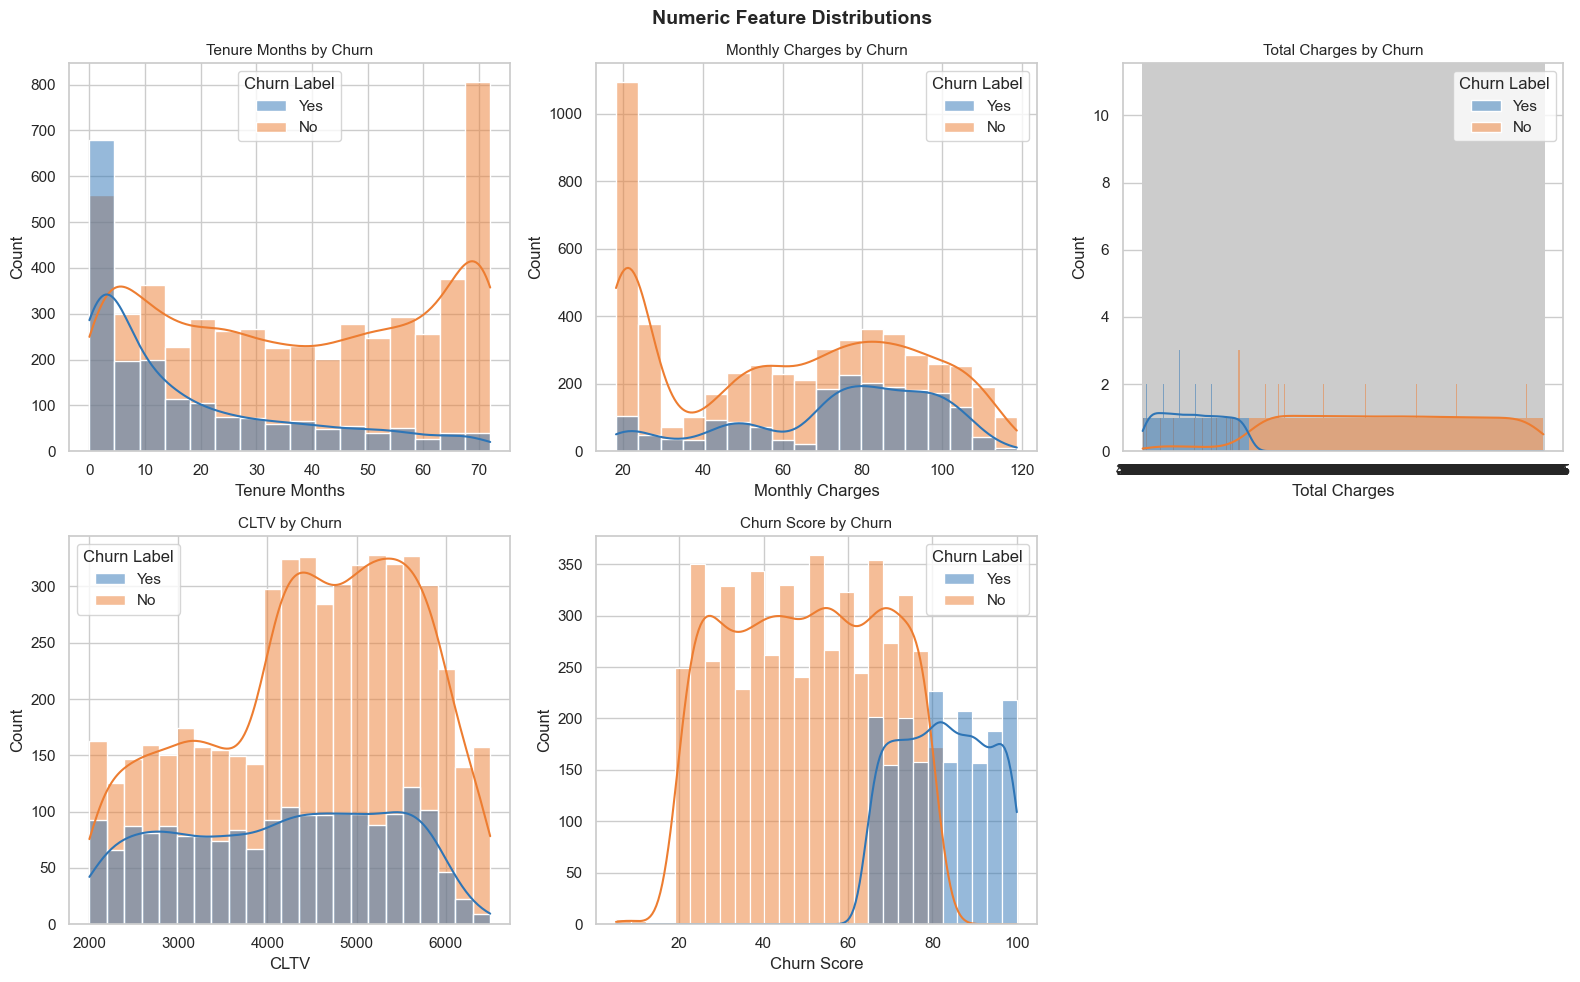

In [24]:
num_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV", "Churn Score"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="Churn Label", kde=True,
                 palette=["#2E75B6","#ED7D31"], ax=axes[i])
    axes[i].set_title(f"{col} by Churn", fontsize=11)

axes[5].axis("off")
plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_DIR + "/data/processed/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Churn Reasons

C:\Users\prath\AppData\Local\Temp\ipykernel_15496\705254014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_reasons.values, y=churn_reasons.index, palette="Reds_r")


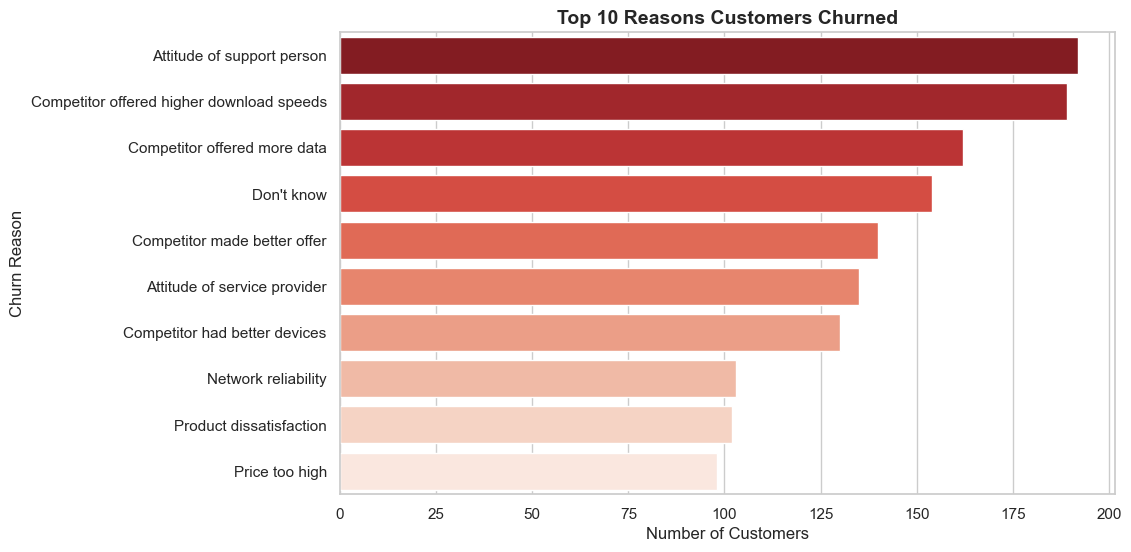

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64


In [25]:
churn_reasons = df[df["Churn Label"] == "Yes"]["Churn Reason"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_reasons.values, y=churn_reasons.index, palette="Reds_r")
plt.title("Top 10 Reasons Customers Churned", fontsize=14, fontweight="bold")
plt.xlabel("Number of Customers")
plt.savefig(BASE_DIR + "/data/processed/churn_reasons.png", dpi=150, bbox_inches="tight")
plt.show()

print(churn_reasons)

# save cleaned dataframe

In [26]:
df.to_csv(BASE_DIR + "/data/processed/telco_features.csv", index=False)
print(f"Saved! Shape: {df.shape}")
print(f"File: {BASE_DIR}/data/processed/telco_features.csv")

Saved! Shape: (7043, 19)
File: c:\Users\prath\OneDrive\Desktop\data_science\customer-churn-project/data/processed/telco_features.csv
